In [1]:
# Imports - all real work lives in helpers.py
from helpers import (
    scan_experiment_structure,
    load_session_recording,
    load_continuous,
    bandpass_filter_emg,
    plot_emg_full_traces,
    make_segment_viewer,
    make_selected_segment_viewer,
    load_message_center_events,
)
from IPython.display import display

In [17]:
# Pick a session, a record-node index (w), and a recording index, then
# load everything in one call. record_node_name / experiment_name /
# recording_name are derived from the actual loaded path.
w               = 1    # recordnodes[0]; bump to 1 for a second record node
recording_index = 0

# directory = 'dEMG_TestN2025-12-19_12-06-47_001'
# directory = 'dEMGpilot2'
# directory = 'dEMGPr1_Test22026-03-05_18-22-35_001'
# directory = 'dEMGPr2_Test22026-03-05_18-49-34_002'
directory = 'dEMGPilot-3_Only_VNS_2026-05-13_12-54-30_001'

session, recording, record_node_name, experiment_name, recording_name = \
    load_session_recording(directory, recordnode_idx=w, recording_idx=recording_index)


Session: dEMGPilot-3_Only_VNS_2026-05-13_12-54-30_001
Loaded:  dEMGPilot-3_Only_VNS_2026-05-13_12-54-30_001\Record Node 111\experiment1\recording1
  record node: Record Node 111
  experiment:  experiment1
  recording:   recording1


In [18]:
# Quick peek at the experiment/recording layout for this record node.
print(scan_experiment_structure(directory, record_node_name))


defaultdict(<class 'list'>, {'experiment1': ['recording1']})


In [19]:
# Pull continuous samples + metadata.
timestamps, data, sample_rate, channel_names = load_continuous(recording)


Sample rate: 5000.0 Hz
Channels (9): ['CH1', 'CH5', 'CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
Data shape: (19795060, 9)


In [20]:
# Bandpass-filter EMG1 (col 4 = CH10), EMG2 (col 5 = CH12), and their differential.
# Pass any channel indices for other channel layouts.
emg1, emg2, differential_filt = bandpass_filter_emg(
    data, ch1_idx=2, ch2_idx=3, sample_rate=sample_rate,
)


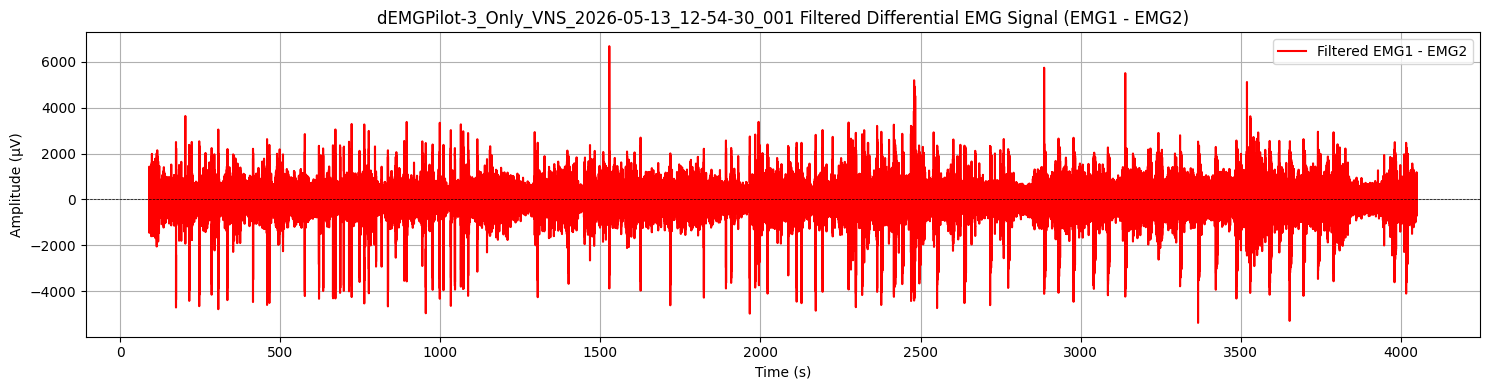

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\src\open_ephys\analysis\helpers.py:6062: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\dal866445\Documents\Github\open-ephys-python-tools\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


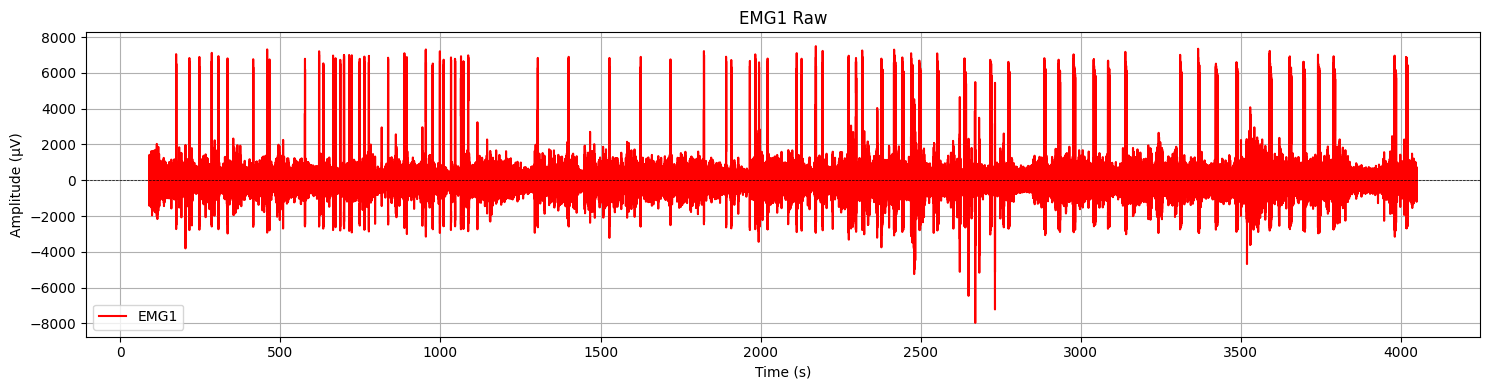

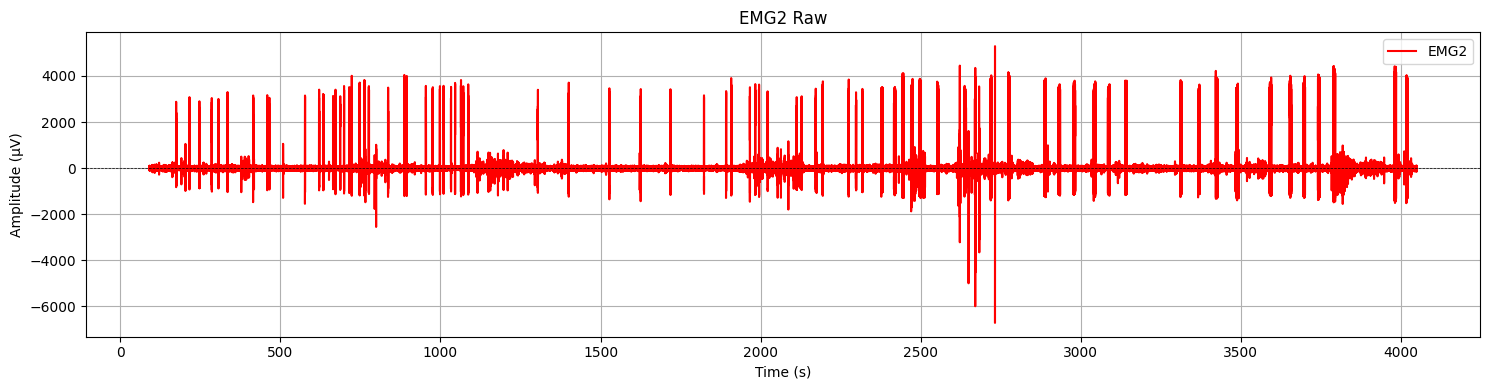

In [21]:
# Three full-trace overview plots: filtered differential, EMG1, EMG2.
plot_emg_full_traces(timestamps, differential_filt, emg1, emg2, directory, color="red")

In [ ]:
# Interactive segmented viewer - 15-second windows.
# Use the "Mark Good" toggle button on any segment you want to keep.
# The returned `selected` set accumulates your picks; run the next cell when done.
viewer, selected = make_segment_viewer(
    timestamps,
    signals=[differential_filt, emg1, emg2],
    labels=["Filtered EMG1 - EMG2", "EMG1 Raw", "EMG2 Raw"],
    segment_duration_s=3,
    title_prefix=f"{directory}, {experiment_name}, {recording_name}",
    color="red",
)
display(viewer)

In [23]:
# After marking good segments above, run this cell to open a viewer
# that shows only those selections (navigates them in time order).
print(f"Selected {len(selected)} segment(s): {sorted(selected)}")
selected_viewer = make_selected_segment_viewer(
    timestamps,
    signals=[differential_filt, emg1, emg2],
    labels=["Filtered EMG1 - EMG2", "EMG1 Raw", "EMG2 Raw"],
    selected_indices=selected,
    segment_duration_s=15,
    title_prefix=f"{directory}, {experiment_name}, {recording_name}",
    color="red",
)
display(selected_viewer)

Selected 0 segment(s): []


In [9]:
# Load MessageCenter events for this recording.
# Returns a list of (timestamp, text) tuples and prints each entry.
message_entries = load_message_center_events(recording.directory)


Loaded 2 MessageCenter entries from dEMGPilot-3_Only_VNS_2026-05-13_12-54-30_001\Record Node 106\experiment1\recording1\events\MessageCenter
